## Model Training


### 1.1 Import Data and Required Packages
Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [2]:
# Basic Import 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
#Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv('data/stud.csv')

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Preparing X and Y variables

In [8]:
X = df.drop(columns=['math score'])

In [9]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [12]:
print("Categorical in 'gender' variable: ",end='')
print(df['gender'].unique())

print("Categorical in 'race/ethnicity' variable: ",end='')
print(df['race/ethnicity'].unique())

print("categorical in 'parental level of education' variable: ",end='')
print(df['parental level of education'].unique())

print("Categorical in 'lunch' variable: ",end='')
print(df['lunch'].unique())

print("Categorical in 'test preparation course' variable is: ",end='')
print(df['test preparation course'].unique())


Categorical in 'gender' variable: <StringArray>
['female', 'male']
Length: 2, dtype: str
Categorical in 'race/ethnicity' variable: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
categorical in 'parental level of education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categorical in 'lunch' variable: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categorical in 'test preparation course' variable is: <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [13]:
y = df['math score']

In [14]:
num_feature = X.select_dtypes(exclude='object').columns
categorical_feature = X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numerical = StandardScaler()
categorical = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('OneHot Encoder',categorical,categorical_feature),
        ('Standard Scaler',numerical,num_feature)
    ]
)


C:\Users\abhin\AppData\Local\Temp\ipykernel_23080\4000269115.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_feature = X.select_dtypes(include='object').columns


In [16]:
X = preprocessor.fit_transform(X)

In [17]:
X.shape

(1000, 19)

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((800, 19), (200, 19))

Create an Evaluate Function to give all metrics after model Training

In [19]:
def evaluate_model(true,pred):
    mae = mean_absolute_error(true,pred)
    mse = mean_squared_error(true,pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true,pred)
    return mae,mse,rmse,r2


In [36]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor(),
    "AdaBoostRegressor": AdaBoostRegressor(),
    "CatBoostRegressor": CatBoostRegressor(verbose=False),
    "XGBRegressor": XGBRegressor()
}

model_list = []
r2_list = []

for name, model in models.items():
    model.fit(X_train,y_train)

    #Make Prediction
    y_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test Dataset
    mae,rmse , mse, r2 = evaluate_model(y_train, y_pred)

    mae ,mse, rmse, r2 = evaluate_model(y_test, y_test_pred)


    print(name)
    model_list.append(name)

    print('Model Performance on Training Dataset')
    print("-Root Mean Squared Error: {:.4f}".format(rmse))
    print("- Mean Absolute Error: {:.4f}".format(mae))
    print("R2 Score: {:.4f}".format(r2))

    print("-------------------------------------------------------------------------")

    print("Model performance on Test Dataset")
    print("- Root Mean Squared Error: {:.4f}".format(rmse))
    print("- Mean Absolute Error: {:.4f}".format(mae))
    print("R2 Score: {:.4f}".format(r2))
    r2_list.append(r2)

    print('='*35)
    print('\n')


LinearRegression
Model Performance on Training Dataset
-Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
R2 Score: 0.8804
-------------------------------------------------------------------------
Model performance on Test Dataset
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
R2 Score: 0.8804


Ridge
Model Performance on Training Dataset
-Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
R2 Score: 0.8806
-------------------------------------------------------------------------
Model performance on Test Dataset
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
R2 Score: 0.8806


Lasso
Model Performance on Training Dataset
-Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
R2 Score: 0.8253
-------------------------------------------------------------------------
Model performance on Test Dataset
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
R2 Score: 0.8253


KNeighborsRegressor
Model Performance on Tra

In [29]:
pd.DataFrame(list(zip(model_list,r2_list)),columns= ['model_name','R2_Score']).sort_values(by=['R2_Score'],ascending=False)

,model_name,R2_Score
1,Ridge,0.880593
0,LinearRegression,0.880433
5,RandomForestRegressor,0.854434
7,CatBoostRegressor,0.851632
6,AdaBoostRegressor,0.851178
8,XGBRegressor,0.827797
2,Lasso,0.825320
3,KNeighborsRegressor,0.783813
4,DecisionTreeRegressor,0.743362


### Linear Regression

In [31]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test,y_pred)*100
print("Accuracy of the Model is %.2f" %score)

Accuracy of the Model is 88.04


## Plot y_pred and y_test

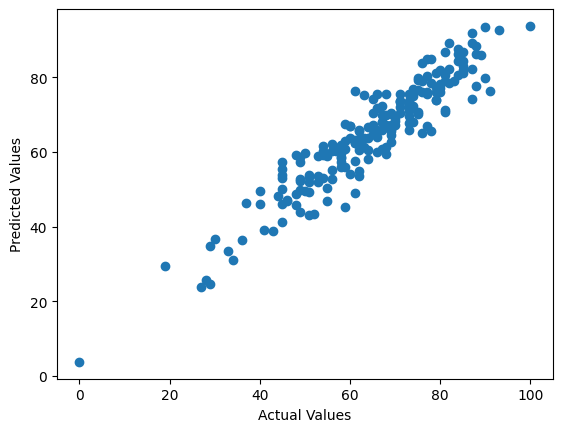

In [32]:
plt.scatter(y_test,y_pred);
plt.xlabel("Actual Values");
plt.ylabel("Predicted Values");

<Axes: xlabel='math score'>

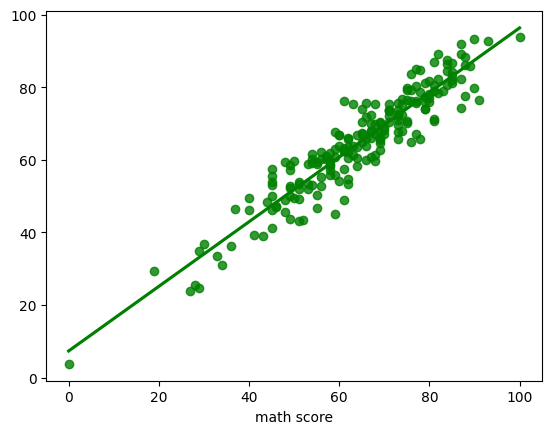

In [34]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='green')

## Difference between Actual and Predicted Values


In [35]:
pred_df = pd.DataFrame({'Actual Value': y_test,'Predicted Value': y_pred,'Differnce': y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Differnce
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
